Name: Manish Giri
Reg. No: 137256
Email: manishgiri8101@gmail.com

#Goal: Compare LOgistic Regression (Supervised) vs K-Means(Unsupervised)

In [42]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [5]:
#Load Dataset
titanic = pd.read_csv("Titanic-Dataset.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#Data Preprocessing

In [10]:
titanic['Age'] = titanic["Age"].fillna(titanic["Age"].median())

In [11]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#EDA

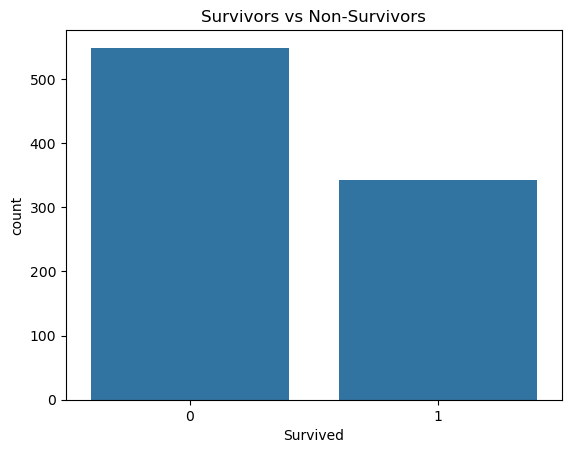

In [21]:
# Survival Count
sns.countplot(x='Survived', data=titanic)
plt.title("Survivors vs Non-Survivors")
plt.show()

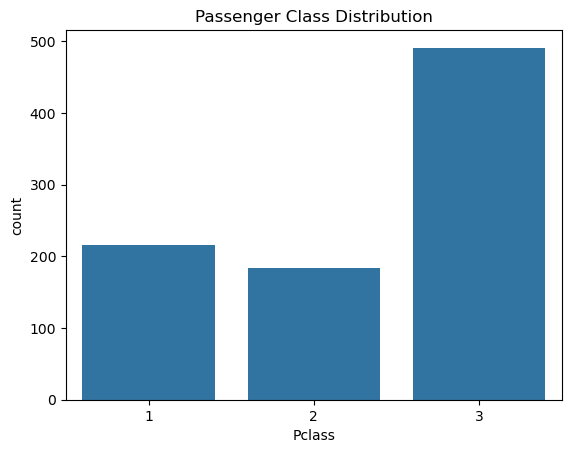

In [22]:
# Passenger Class Distribution
sns.countplot(x='Pclass', data=titanic)
plt.title("Passenger Class Distribution")
plt.show()

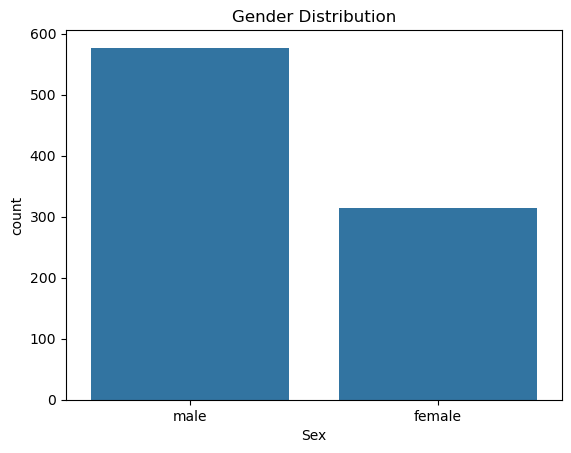

In [23]:
# Gender Distribution
sns.countplot(x='Sex', data=titanic)
plt.title("Gender Distribution")
plt.show()

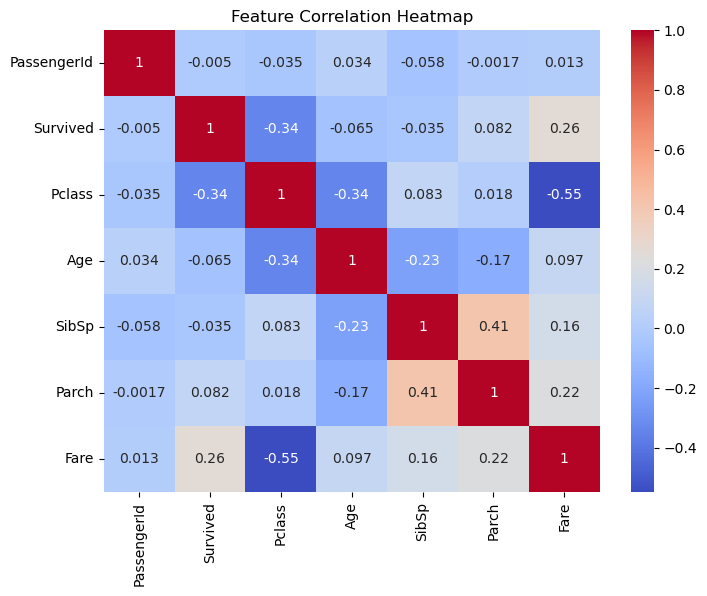

In [20]:
#Relationship among numeric features
plt.figure(figsize=(8,6))

numeric_cols = titanic.select_dtypes(include=['number'])

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

#Feature Eng.

In [12]:
#Select Feature and target
X = titanic[["Age", "Pclass", "Sex"]]
y = titanic["Survived"]

In [13]:
X['Sex'] = X['Sex'].map({'male':0, 'female':1})

C:\Users\Manish Giri\AppData\Local\Temp\ipykernel_18700\3201343990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = X['Sex'].map({'male':0, 'female':1})


#train-test-split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Part 1: Supervised Learning || Goal - Predict survival Using Logistic Regression

In [15]:
#Train Model
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [17]:
#Predict
y_pred = log_model.predict(X_test)

In [28]:
#Evaluate
print("Supervised Learning (Logistic Regression):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report: \n",classification_report(y_test, y_pred))

Supervised Learning (Logistic Regression):
Accuracy: 0.81
Classification Report: 
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Confusion Matrix :
 [[91 14]
 [20 54]]


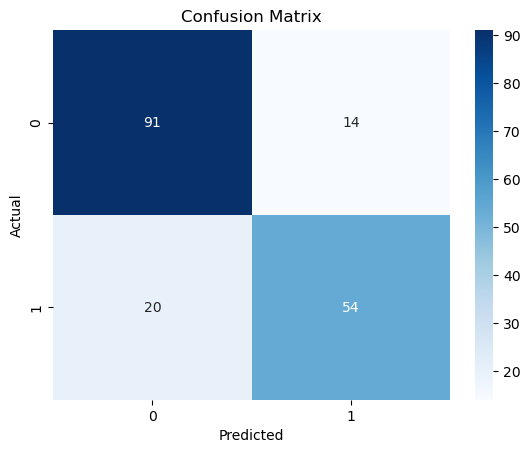

In [26]:
print("Confusion Matrix :\n",confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Part 1: Unsupervised Learning || Goal: Grouping passanagers and shows cetagorical relation between Age, Fare and Clusters.

In [30]:
print(titanic.isna().sum())
print(titanic.columns)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [32]:
X_cluster = titanic[['Age', 'Fare', 'Pclass']]

In [33]:
#Apply k-means
kmeans = KMeans(n_clusters=3, random_state=42)
titanic['Cluster'] = kmeans.fit_predict(X_cluster)

c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have

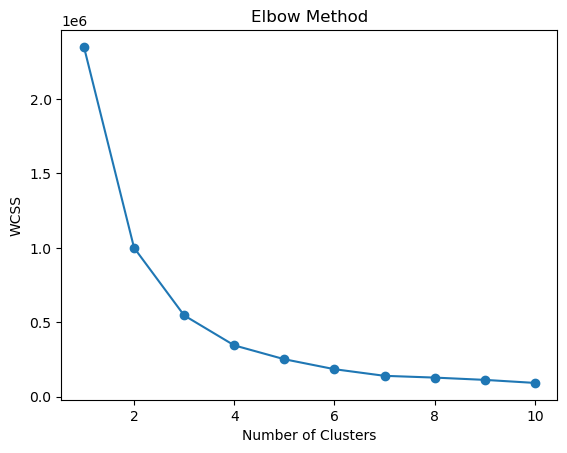

In [38]:
#justify why 3 classters selected
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42
    )
    km.fit(X_cluster)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [34]:
#Show Cluster centers
print("Unsupervised Learning(K-Means clustering)")
print("Cluster Centers: \n",kmeans.cluster_centers_)

Unsupervised Learning(K-Means clustering)
Cluster Centers: 
 [[ 28.27880658  15.45395432   2.55144033]
 [ 30.85       279.308545     1.        ]
 [ 34.71070423  83.39327958   1.24647887]]


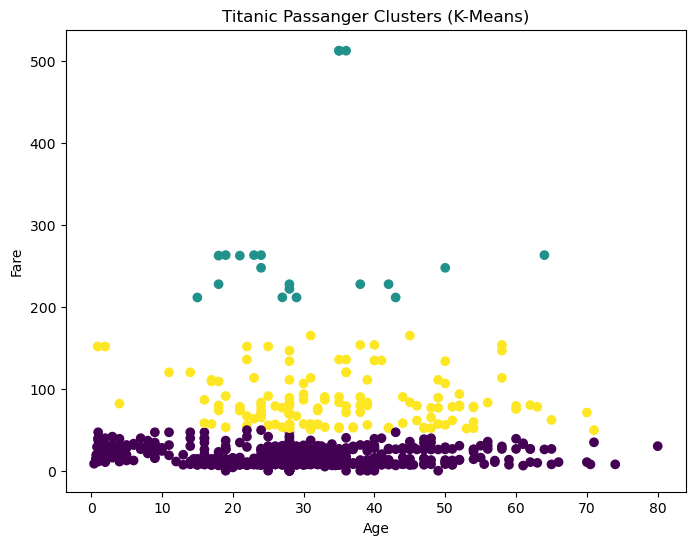

In [35]:
#Visualiza clusters
plt.figure(figsize=(8,6))
plt.scatter(titanic['Age'], titanic['Fare'], c=titanic['Cluster'], cmap='viridis')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Passanger Clusters (K-Means)")
plt.show()

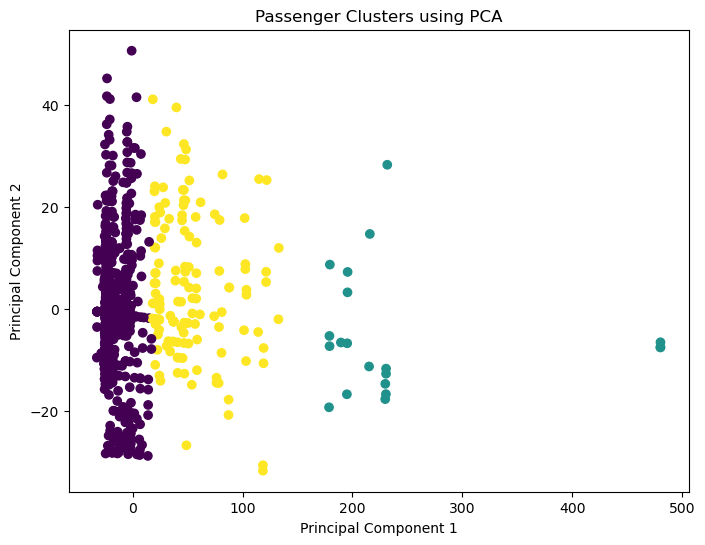

In [ ]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=titanic['Cluster'],
    cmap='viridis'
)

plt.title("Passenger Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
score = silhouette_score(
    X_cluster,
    titanic['Cluster']
)

print(
    "Silhouette Score:",
    round(score,3)
)

Silhouette Score: 0.664


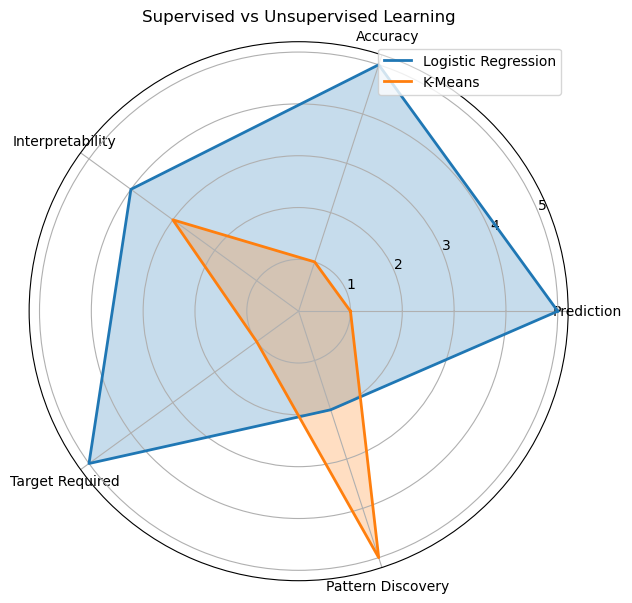

In [41]:
import numpy as np

categories = [
    'Prediction',
    'Accuracy',
    'Interpretability',
    'Target Required',
    'Pattern Discovery'
]

logistic = [5,5,4,5,2]
kmeans = [1,1,3,1,5]

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

logistic += logistic[:1]
kmeans += kmeans[:1]
angles += angles[:1]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    logistic,
    linewidth=2,
    label='Logistic Regression'
)

ax.fill(
    angles,
    logistic,
    alpha=0.25
)

ax.plot(
    angles,
    kmeans,
    linewidth=2,
    label='K-Means'
)

ax.fill(
    angles,
    kmeans,
    alpha=0.25
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title(
    "Supervised vs Unsupervised Learning"
)

plt.legend(
    loc='upper right'
)

plt.show()